#### 연습 문제 
1. 5월 19일 날짜에 작업했던 하이닉스 주식 데이터를 로드하는 방법(야후 파이낸스)을 이용
    - 야후파이낸스에서 일별 데이터를 로드하는 기간은 2000년부터 가능
2. opendartreader 라이브러리를 이용해서 영업이익 데이터를 로드 
    - env 활용해서 api_key 데이터 공유 금지 
    - Dart 전자공시 2015년 부터 전자공시 필수화 (15년 이후의 공시 데이터를 서치 가능)
    - 15년 이전의 데이터들은 웹크롤링을 이용하여 노가다

3. 주가의 데이터는 15년부터 불러오고 영업이익 데이터도 15년부터 데이터를 로드하여 데이터를 결합
    - 영업이익이 존재하지 않는 데이터들은 제거 (결측치 제거)

4. 이동 평균선(20일)을 생성하고 이격도 컬럼을 생성

5. 종가, 거래량, 이격도, 영업이익 데이터를 이용하여 LSTM 모델에 학습 데이터로 이용 

6. train, test 비율을 85:15로 생성하여 데이터 예측 모델을 생성 

7. epoch = 20, window = 60, 학습 배치 갯수 = 32, 검증 배치 개수 = 32, lr = 0.001

In [89]:
import pandas as pd 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
import OpenDartReader
from datetime import datetime 
import os 
from dotenv import load_dotenv
import time 

In [90]:
hynix = yf.Ticker("000660.KS")
df = hynix.history(period='12y')
# df = hynix.history(start="2015-01-01")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-05-27 00:00:00+09:00,36715.768532,36758.862157,36241.738656,36371.019531,1206673,0.0,0.0
2014-05-28 00:00:00+09:00,36845.054330,36845.054330,36543.398914,36715.773438,2267797,0.0,0.0
2014-05-29 00:00:00+09:00,36801.960699,36974.335222,36586.492545,36715.773438,2788250,0.0,0.0
2014-05-30 00:00:00+09:00,36715.761927,38051.664062,36715.761927,38051.664062,5719933,0.0,0.0
2014-06-02 00:00:00+09:00,38094.762986,38956.635452,38051.669363,38525.699219,2594762,0.0,0.0


In [91]:
df = df.loc[df.index > "2015-01-01"]
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00+09:00,4.159227e+04,4.198261e+04,4.133205e+04,4.141879e+04,1155944,0.0,0.0
2015-01-05 00:00:00+09:00,4.167901e+04,4.198260e+04,4.120194e+04,4.133205e+04,1409146,0.0,0.0
2015-01-06 00:00:00+09:00,4.076823e+04,4.128867e+04,4.068149e+04,4.120193e+04,1661196,0.0,0.0
2015-01-07 00:00:00+09:00,4.050801e+04,4.128868e+04,4.050801e+04,4.111520e+04,1821266,0.0,0.0
2015-01-08 00:00:00+09:00,4.185249e+04,4.337046e+04,4.154890e+04,4.332709e+04,5006675,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-20 00:00:00+09:00,1.743000e+06,1.778000e+06,1.690000e+06,1.745000e+06,5535123,0.0,0.0
2026-05-21 00:00:00+09:00,1.801000e+06,1.954000e+06,1.796000e+06,1.940000e+06,5096690,0.0,0.0
2026-05-22 00:00:00+09:00,1.942000e+06,1.952000e+06,1.912000e+06,1.941000e+06,3135190,0.0,0.0


In [92]:
# 종가, 거래량을 제외한 나머지 컬럼들을 제외 (특정 컬럼만 선택 )
df = df[ ['Close', 'Volume'] ]
# 이동평균선 
df['MA20'] = df['Close'].rolling(20).mean()
df.head()


C:\Users\신재호\AppData\Local\Temp\ipykernel_26216\388427343.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA20'] = df['Close'].rolling(20).mean()


,Close,Volume,MA20
Date,,,
2015-01-02 00:00:00+09:00,41418.789062,1155944,NaN
2015-01-05 00:00:00+09:00,41332.046875,1409146,NaN
2015-01-06 00:00:00+09:00,41201.933594,1661196,NaN
2015-01-07 00:00:00+09:00,41115.195312,1821266,NaN
2015-01-08 00:00:00+09:00,43327.089844,5006675,NaN


In [93]:
# .env 파일의 정보를 로드 
load_dotenv()

True

In [94]:
api_key = os.getenv('api_key')

In [95]:
dart = OpenDartReader(api_key)

In [96]:
# 2015년부터 2026년까지 년도별 영업이익을 구하기 위해 연도 list 생성 
# 현재의 년도 
current_year = datetime.now().year
years = range(2015, current_year+1)
years

range(2015, 2027)

In [97]:
# 보고서 리스트 생성 
reprt_codes = ['11013', '11012', '11014', '11011']
dart_data_list = []

In [98]:
for year in years:
    for code in reprt_codes:
        try : 
            report = dart.finstate('000660', year, code)
            if report is not None:
                op_profit = report[ (report['fs_div'] == 'CFS')  & ( report['account_nm'] == '영업이익' ) ]
                if not op_profit.empty:
                    val = int(
                            op_profit['thstrm_amount'].values[0].replace(',', '')
                        )
                    # code 11013 -> 1분기 보고서 
                    if code == '11013' : d = f"{year}-05-15"
                    elif code == '11012' : d = f"{year}-08-14"
                    elif code == '11014' : d = f"{year}-11-14"
                    else : d = f"{year+1}-03-31"

                    report_date = pd.to_datetime(d)
                    if report_date <= datetime.now():
                        dart_data_list.append({'Date' : report_date, 'Operation_Profit' : val})
            time.sleep(1)
        except: continue
dart_data_list

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}



[{'Date': Timestamp('2016-03-31 00:00:00'), 'Operation_Profit': 5336100000000},
 {'Date': Timestamp('2016-05-15 00:00:00'), 'Operation_Profit': 561798000000},
 {'Date': Timestamp('2016-08-14 00:00:00'), 'Operation_Profit': 452853000000},
 {'Date': Timestamp('2016-11-14 00:00:00'), 'Operation_Profit': 725956000000},
 {'Date': Timestamp('2017-03-31 00:00:00'), 'Operation_Profit': 3276746000000},
 {'Date': Timestamp('2017-05-15 00:00:00'), 'Operation_Profit': 2467599000000},
 {'Date': Timestamp('2017-08-14 00:00:00'), 'Operation_Profit': 3050700000000},
 {'Date': Timestamp('2017-11-14 00:00:00'), 'Operation_Profit': 3737193000000},
 {'Date': Timestamp('2018-03-31 00:00:00'),
  'Operation_Profit': 13721326000000},
 {'Date': Timestamp('2018-05-15 00:00:00'), 'Operation_Profit': 4367338000000},
 {'Date': Timestamp('2018-08-14 00:00:00'), 'Operation_Profit': 5573918000000},
 {'Date': Timestamp('2018-11-14 00:00:00'), 'Operation_Profit': 6472420000000},
 {'Date': Timestamp('2019-03-31 00:00:00

In [99]:
# 시간, 영업이익 데이터를 데이터프레임 생성 
dart_df = pd.DataFrame(dart_data_list)
dart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              42 non-null     datetime64[ns]
 1   Operation_Profit  42 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 800.0 bytes


In [100]:
display(df.head(1))
display(dart_df.head(1))

,Close,Volume,MA20
Date,,,
2015-01-02 00:00:00+09:00,41418.789062,1155944,NaN


,Date,Operation_Profit
0,2016-03-31,5336100000000


In [101]:
# 결합 전 df의 timezone을 제거 
df.index = df.index.tz_localize(None)

In [102]:
df = pd.merge_asof(df, dart_df, left_index=True, right_on='Date', direction='backward')

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2793 entries, 2015-01-02 to 2026-05-27
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Close             2793 non-null   float64       
 1   Volume            2793 non-null   int64         
 2   MA20              2774 non-null   float64       
 3   Date              2793 non-null   datetime64[ns]
 4   Operation_Profit  2485 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 130.9 KB


In [104]:
# 결측치가 포함되어있는 인덱스는 제거 
df.dropna(inplace=True)

In [105]:
df.head(3)

,Close,Volume,MA20,Date,Operation_Profit
Date,,,,,
2016-03-31,24819.169922,4336581,26311.407227,2016-03-31,5.336100e+12
2016-04-01,24863.251953,2991431,26148.296973,2016-04-01,5.336100e+12
2016-04-04,24598.753906,2823088,25971.961816,2016-04-04,5.336100e+12


In [106]:
# 이격도 
df['Dist_MA20'] = ( df['Close'] - df['MA20']  ) / df['MA20']

In [107]:
x = df[['Close', 'Volume', 'Operation_Profit', 'Dist_MA20']].values
y = df[['Close']].values

In [108]:
split_idx = int(len(df) * 0.85)
X_train, X_test = x[ : split_idx], x[split_idx : ]
y_train, y_test = y[ : split_idx], y[split_idx : ]

In [109]:
# 스케일링 작업 
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(y_train)

X_train_sc = x_scaler.transform(X_train)
X_test_sc = x_scaler.transform(X_test)
y_train_sc = y_scaler.transform(y_train)
y_test_sc = y_scaler.transform(y_test)

In [110]:
# 딥러닝 초기 값들을 미리 지정 
window = 60
epochs = 20
train_batch = 32
test_batch = 32
lr = 0.001
hidden_cnt = 64
head_type = 'c'

In [111]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y =_y
        self.window = _window
        self.n = len(_x) - _window
    
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        x = self.x[idx : idx + self.window]
        y = self.y[idx + self.window]

        x_tensor = torch.from_numpy(x)
        y_tensor = torch.tensor(y)

        return x_tensor, y_tensor

In [112]:
# DS 생성 
train_ds = windowDS(X_train_sc, y_train_sc, window)
test_ds = windowDS(X_test_sc, y_test_sc, window)

In [113]:
# DataLoader 생성 
train_dl = DataLoader(train_ds, shuffle = True, drop_last = True, batch_size=train_batch)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=test_batch)

In [114]:
class LSTMModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            num_layers = 1, 
            dropout = 0.0, 
            bidirectional = False, 
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers= num_layers, 
            dropout= dropout, 
            bidirectional= bidirectional, 
            batch_first= True
        )
        
        hidden_size = hidden_size * (2 if bidirectional else 1)
        if head_type in ['h', 'c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim=-1 )
        
        return self.model(feat)
        


In [115]:
model = LSTMModel(input_size = x.shape[1], hidden_size= hidden_cnt, head_type=head_type)

In [116]:
model

LSTMModel(
  (lstm): LSTM(4, 64, batch_first=True)
  (model): Linear(in_features=64, out_features=1, bias=True)
)

In [117]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

In [118]:
# 검증 데이터를 이용하여 mse 값을 구하는 함수 
@torch.no_grad()
def evaluate_mse(dl):
    model.eval()
    total_loss, total_n = 0.0, 0
    for x, y in dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        loss = criterion(pred, y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

In [119]:
for epoch in range(epochs):
    model.train()
    total_loss, total_n = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    train_loss = total_loss / max(total_n, 1)
    test_loss = evaluate_mse(test_dl)

    print(f"Epoch : {epoch}, train_mse : {train_loss}, test_loss : {test_loss}")

Epoch : 0, train_mse : 0.03151940524185193, test_loss : 0.24348460847196488
Epoch : 1, train_mse : 0.0013483693023772503, test_loss : 0.4269450609557354
Epoch : 2, train_mse : 0.000439953769728163, test_loss : 0.9921275931782425
Epoch : 3, train_mse : 0.0002764287316949776, test_loss : 1.2212331707532795
Epoch : 4, train_mse : 0.0002504821167690352, test_loss : 1.287519557193255
Epoch : 5, train_mse : 0.00025401311495443224, test_loss : 1.3120113522433245
Epoch : 6, train_mse : 0.0002767138786339274, test_loss : 1.2590371877811968
Epoch : 7, train_mse : 0.0002415084630911224, test_loss : 1.1947879823632896
Epoch : 8, train_mse : 0.00023828573279160992, test_loss : 1.154358441492144
Epoch : 9, train_mse : 0.0002477093132711161, test_loss : 1.172691123339886
Epoch : 10, train_mse : 0.000250013777872482, test_loss : 1.1033257527616078
Epoch : 11, train_mse : 0.00023862723003276187, test_loss : 1.1433218002866823
Epoch : 12, train_mse : 0.00022832176045994856, test_loss : 1.13419781985898


In [120]:
model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)
    
preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()

pred_origin = y_scaler.inverse_transform(preds).squeeze()
true_origin = y_scaler.inverse_transform(trues).squeeze()

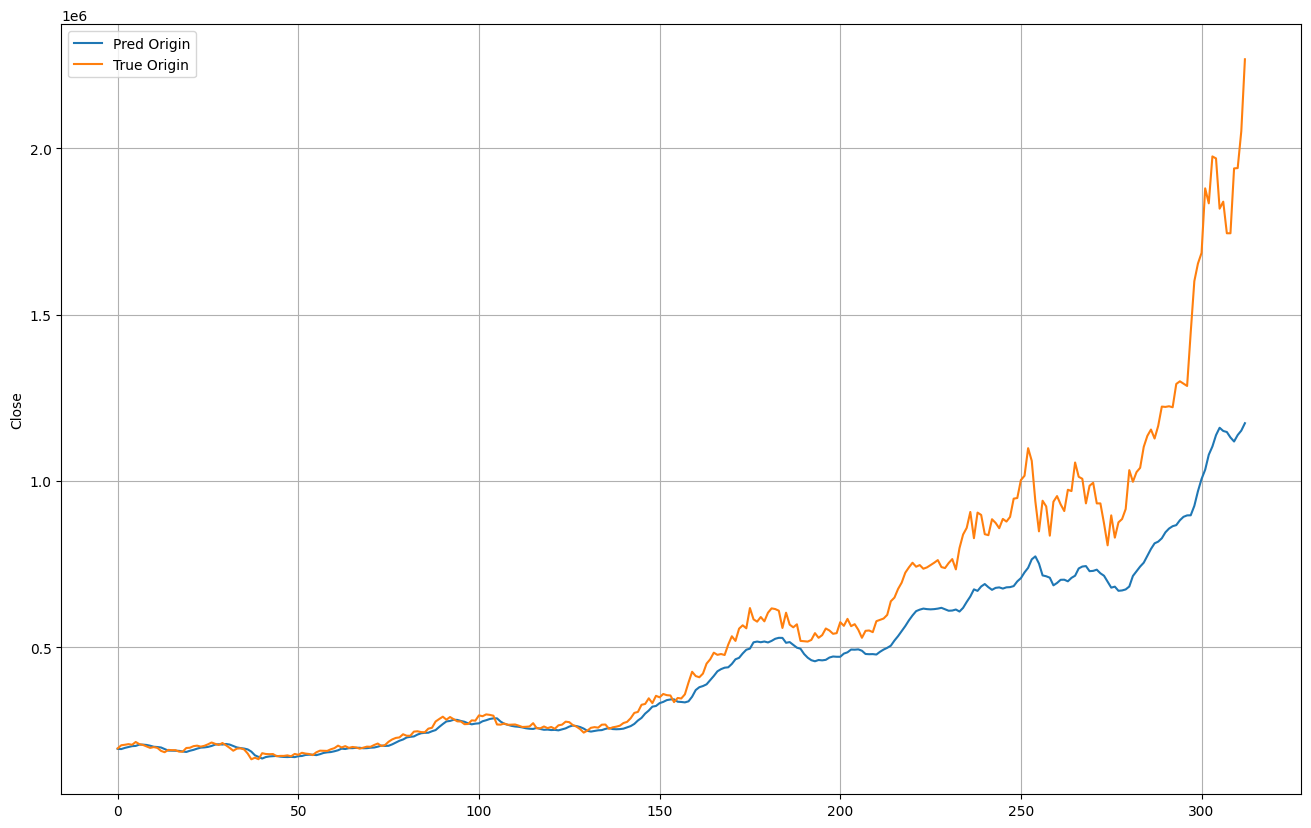

In [121]:
plt.figure(figsize=(16, 10))

plt.plot(pred_origin, label = 'Pred Origin')
plt.plot(true_origin, label='True Origin')
plt.legend()
plt.grid()
plt.ylabel('Close')
# 그림으로 저장 
plt.savefig('하이닉스.png')
plt.show()

In [122]:
hynix = yf.Ticker("000660.KS")
df = hynix.history(period='1y')
# df = hynix.history(start="2015-01-01")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-05-27 00:00:00+09:00,199339.002894,202321.631366,198841.898148,201327.421875,1424916,0.0,0.0
2025-05-28 00:00:00+09:00,205304.263860,208286.892390,204807.159105,206795.578125,3161188,0.0,0.0
2025-05-29 00:00:00+09:00,213643.122457,213643.122457,206671.085827,211153.109375,3827689,375.0,0.0
2025-05-30 00:00:00+09:00,209161.075031,209161.075031,202189.039196,203683.046875,4826628,0.0,0.0
2025-06-02 00:00:00+09:00,204181.065136,207667.083321,202189.054744,206671.078125,1775752,0.0,0.0


In [123]:
df.reset_index(inplace=True)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                     
---  ------        --------------  -----                     
 0   Date          243 non-null    datetime64[ns, Asia/Seoul]
 1   Open          243 non-null    float64                   
 2   High          243 non-null    float64                   
 3   Low           243 non-null    float64                   
 4   Close         243 non-null    float64                   
 5   Volume        243 non-null    int64                     
 6   Dividends     243 non-null    float64                   
 7   Stock Splits  243 non-null    float64                   
dtypes: datetime64[ns, Asia/Seoul](1), float64(6), int64(1)
memory usage: 15.3 KB


In [125]:
df['Date'] = df['Date'].dt.date.astype('datetime64[s]')

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   Date          243 non-null    datetime64[s]
 1   Open          243 non-null    float64      
 2   High          243 non-null    float64      
 3   Low           243 non-null    float64      
 4   Close         243 non-null    float64      
 5   Volume        243 non-null    int64        
 6   Dividends     243 non-null    float64      
 7   Stock Splits  243 non-null    float64      
dtypes: datetime64[s](1), float64(6), int64(1)
memory usage: 15.3 KB


In [127]:
dart_df['Date'] = dart_df['Date'].astype('datetime64[s]')
dart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   Date              42 non-null     datetime64[s]
 1   Operation_Profit  42 non-null     int64        
dtypes: datetime64[s](1), int64(1)
memory usage: 800.0 bytes


In [128]:
pd.merge_asof(df, dart_df, on = 'Date', direction='backward')

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Operation_Profit
0,2025-05-27,1.993390e+05,2.023216e+05,1.988419e+05,2.013274e+05,1424916,0.0,0.0,7440504000000
1,2025-05-28,2.053043e+05,2.082869e+05,2.048072e+05,2.067956e+05,3161188,0.0,0.0,7440504000000
2,2025-05-29,2.136431e+05,2.136431e+05,2.066711e+05,2.111531e+05,3827689,375.0,0.0,7440504000000
3,2025-05-30,2.091611e+05,2.091611e+05,2.021890e+05,2.036830e+05,4826628,0.0,0.0,7440504000000
4,2025-06-02,2.041811e+05,2.076671e+05,2.021891e+05,2.066711e+05,1775752,0.0,0.0,7440504000000
...,...,...,...,...,...,...,...,...,...
238,2026-05-20,1.743000e+06,1.778000e+06,1.690000e+06,1.745000e+06,5535123,0.0,0.0,37610283000000
239,2026-05-21,1.801000e+06,1.954000e+06,1.796000e+06,1.940000e+06,5096690,0.0,0.0,37610283000000
240,2026-05-22,1.942000e+06,1.952000e+06,1.912000e+06,1.941000e+06,3135190,0.0,0.0,37610283000000
241,2026-05-26,2.008000e+06,2.087000e+06,2.006000e+06,2.052000e+06,4903591,0.0,0.0,37610283000000
